In [1]:
import pandas as pd 

sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
vitri = pd.read_csv("../data/clean/dm_vi_tri_clean.csv")
tonkho = pd.read_csv("../data/clean/xnk_ton_kho_clean.csv")
cham = pd.read_csv("../data/clean/log_cham_hang.csv")
xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_17836\3108154871.py:3: DtypeWarning: Columns (6,32,39) have mixed types. Specify dtype option on import or set low_memory=False.
  sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_17836\3108154871.py:7: DtypeWarning: Columns (9,31,34) have mixed types. Specify dtype option on import or set low_memory=False.
  xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_17836\3108154871.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")


In [2]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [3]:
import importlib
import src.feature.feature
import src.feature.merge

importlib.reload(src.feature.feature)
importlib.reload(src.feature.merge)


<module 'src.feature.merge' from 'e:\\TKsolution\\warehouse AI\\src\\feature\\merge.py'>

In [4]:
from src.feature.merge import build_feature_table

feature_table = build_feature_table(
    sanpham,
    tonkho,
    nhapkho,
    xuatkho,
    cham,
    vitri
)

In [5]:
from pathlib import Path

Path("../data/process").mkdir(parents=True, exist_ok=True)

feature_table.to_csv(
    "../data/process/classic_feature.csv",
    index=False,
    encoding="utf-8-sig"
)

In [6]:
feature = pd.read_csv("../data/process/classic_feature.csv")

In [7]:
feature_kho_1 = (
    feature_table
    .query("kho_id == 12473657")
    .reset_index(drop=True)
)

feature_kho_2 = (
    feature_table
    .query("kho_id == 12630825")
    .reset_index(drop=True)
)

feature_kho_3 = (
    feature_table
    .query("kho_id == 12630830")
    .reset_index(drop=True)
)

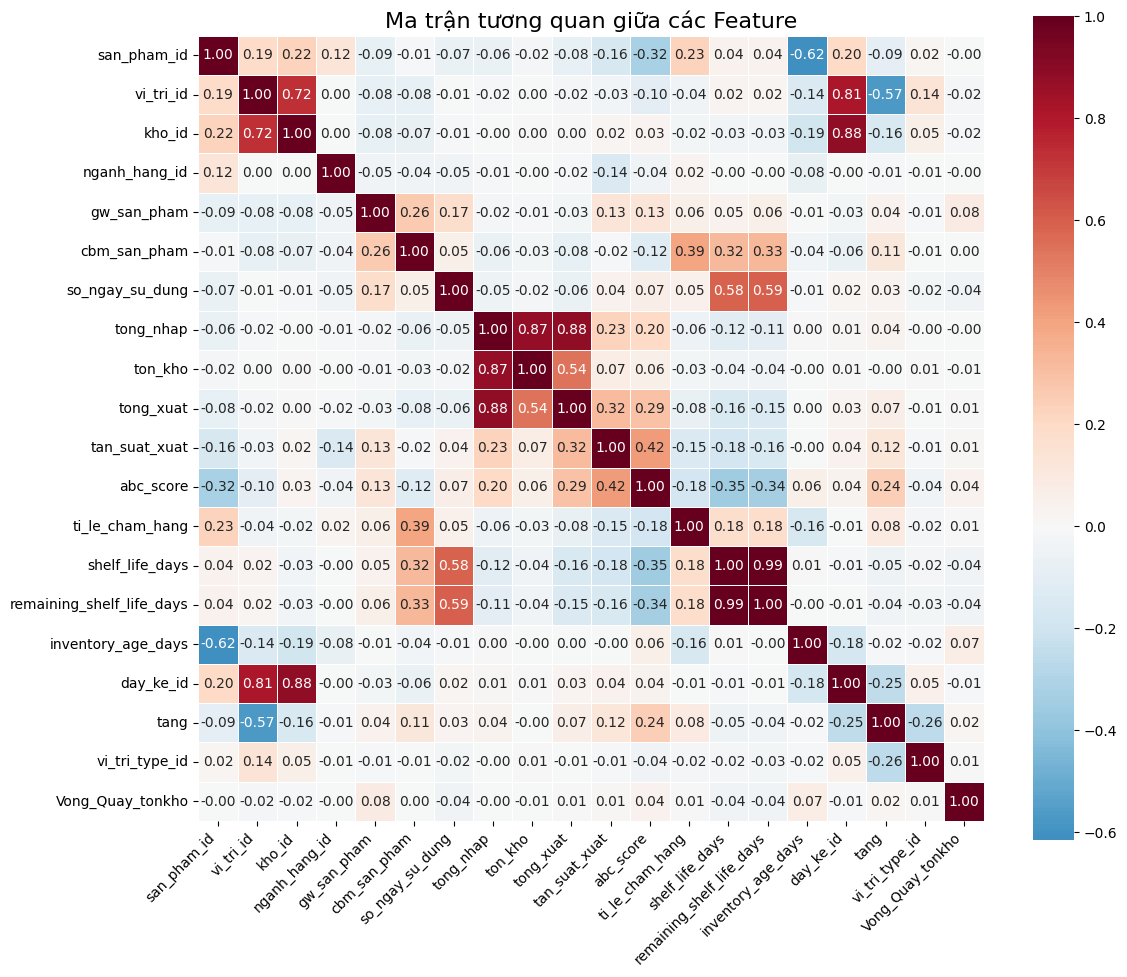

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Chỉ lấy các cột số
corr = feature_table.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    annot=True,          # Hiển thị hệ số tương quan
    fmt=".2f",
    cmap="RdBu_r",       # Đỏ: tương quan dương, Xanh: tương quan âm
    center=0,
    linewidths=0.5,
    square=True
)

plt.title("Ma trận tương quan giữa các Feature", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
corr["vi_tri_id"].sort_values(ascending=False)

vi_tri_id                    1.000000
day_ke_id                    0.811955
kho_id                       0.722447
san_pham_id                  0.194438
vi_tri_type_id               0.137163
shelf_life_days              0.021823
remaining_shelf_life_days    0.019386
nganh_hang_id                0.001527
ton_kho                      0.000468
so_ngay_su_dung             -0.009827
tong_nhap                   -0.015342
tong_xuat                   -0.019873
Vong_Quay_tonkho            -0.020025
tan_suat_xuat               -0.032556
ti_le_cham_hang             -0.043021
cbm_san_pham                -0.080841
gw_san_pham                 -0.084738
abc_score                   -0.100327
inventory_age_days          -0.139969
tang                        -0.568156
Name: vi_tri_id, dtype: float64

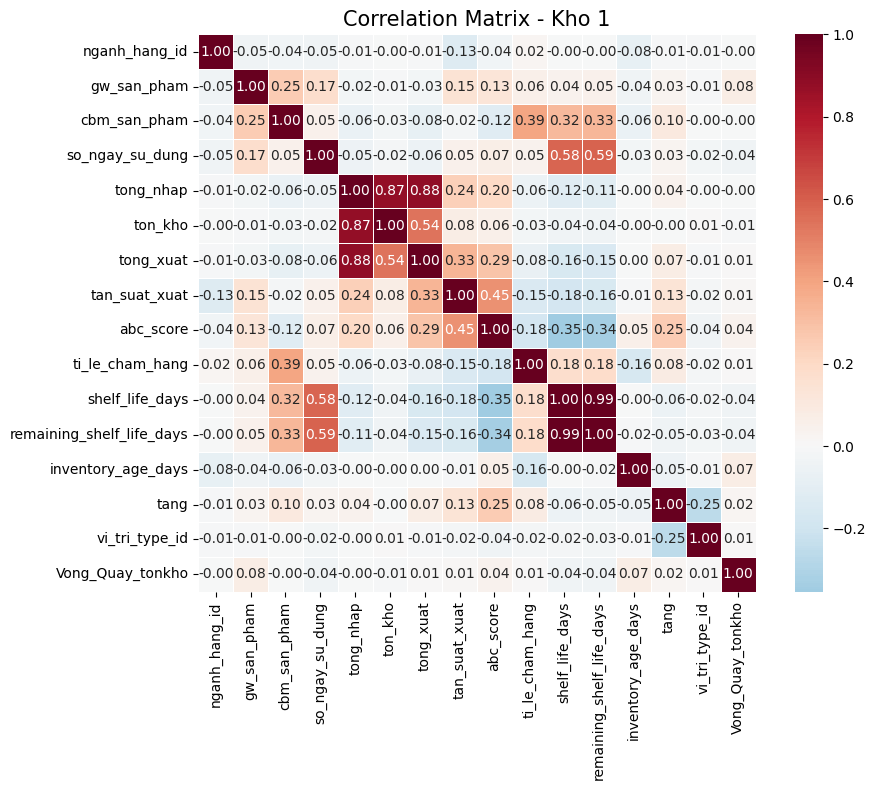

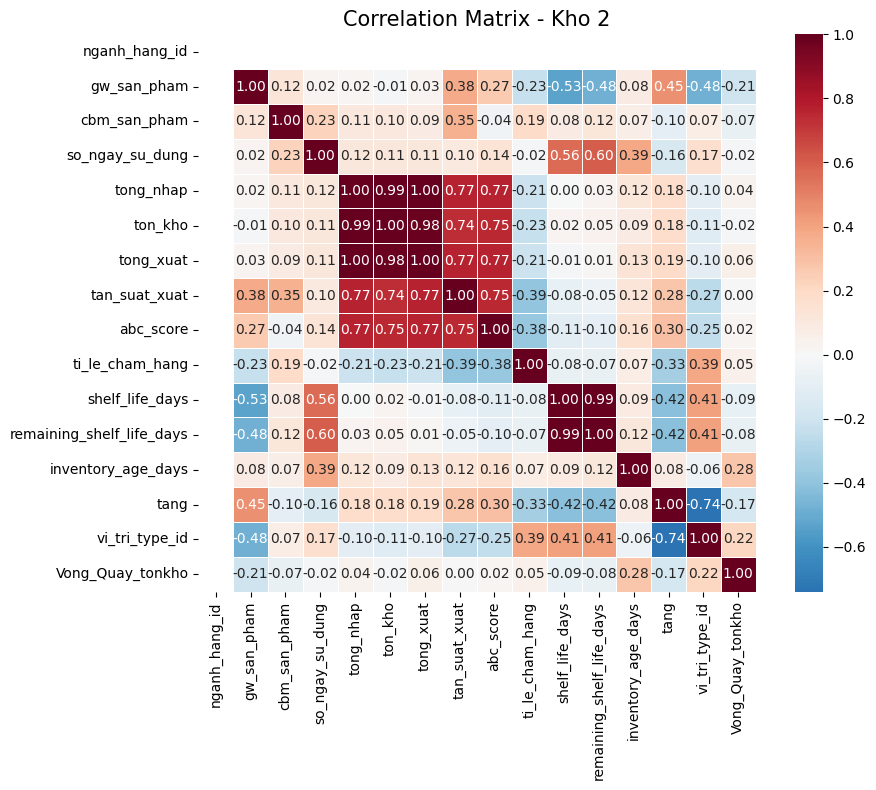

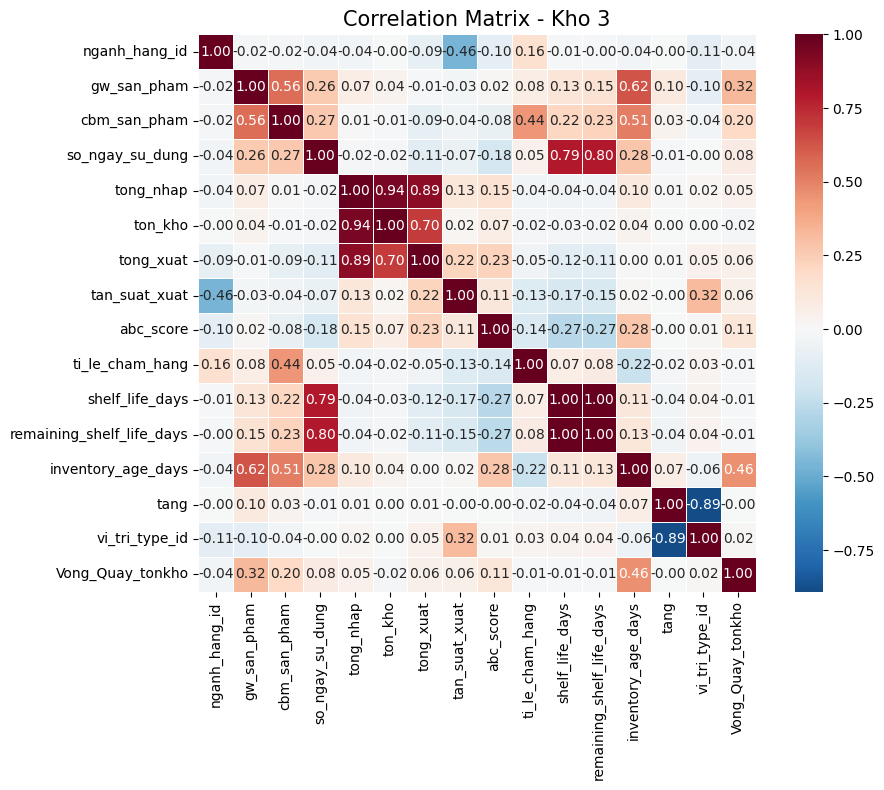

In [10]:
warehouse_data = {
    "Kho 1": feature_kho_1,
    "Kho 2": feature_kho_2,
    "Kho 3": feature_kho_3,
}

drop_cols = [
    "san_pham_id",
    "vi_tri_id",
    "kho_id",
    "day_ke_id"
]

for name, df in warehouse_data.items():

    corr = (
        df
        .drop(columns=drop_cols, errors="ignore")
        .select_dtypes(include="number")
        .corr()
    )

    plt.figure(figsize=(10, 8))

    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        cmap="RdBu_r",
        center=0,
        linewidths=0.5,
        square=True,
    )

    plt.title(f"Correlation Matrix - {name}", fontsize=15)

    plt.tight_layout()
    plt.show()

In [11]:
print("Kho 1:", feature_kho_1.shape)
print("Kho 2:", feature_kho_2.shape)
print("Kho 3:", feature_kho_3.shape)

Kho 1: (176867, 22)
Kho 2: (66, 22)
Kho 3: (2860, 22)


In [12]:
tonkho["kho_id"].value_counts()

kho_id
12473657    684500
12630830      8005
12630825       147
Name: count, dtype: int64

In [13]:
feature_table["kho_id"].value_counts()

kho_id
12473657    176867
12630830      2860
12630825        66
Name: count, dtype: int64

In [14]:
for name, df in [
    ("Kho 1", feature_kho_1),
    ("Kho 2", feature_kho_2),
    ("Kho 3", feature_kho_3),
]:
    print("=" * 40)
    print(name)
    print("Số mẫu:", len(df))
    print("Số vị trí:", df["vi_tri_id"].nunique())
    print(df["vi_tri_id"].value_counts().head(10))

Kho 1
Số mẫu: 176867
Số vị trí: 14355
vi_tri_id
20036994    5767
20036974    4932
12473833    4292
20036980    4104
20036982    3117
20036976    3046
20036978    2520
24488188    1904
12853309    1867
20036984    1714
Name: count, dtype: int64
Kho 2
Số mẫu: 66
Số vị trí: 36
vi_tri_id
52232866    31
52225311     1
52225682     1
52225281     1
52226023     1
52225293     1
52225047     1
52224559     1
52223547     1
52224294     1
Name: count, dtype: int64
Kho 3
Số mẫu: 2860
Số vị trí: 45
vi_tri_id
49648529    2317
49658977     242
49648527     220
49648525      40
49657103       1
49657041       1
49657043       1
49657045       1
49657055       1
49657077       1
Name: count, dtype: int64


In [15]:
print(feature_kho_1["vi_tri_id"].nunique())
print(feature_kho_1["vi_tri_id"].value_counts().describe())

14355
count    14355.000000
mean        12.320933
std         98.051417
min          1.000000
25%          3.000000
50%          6.000000
75%         14.000000
max       5767.000000
Name: count, dtype: float64


In [16]:
feature_kho_1["vi_tri_id"].value_counts().head(20)

vi_tri_id
20036994    5767
20036974    4932
12473833    4292
20036980    4104
20036982    3117
20036976    3046
20036978    2520
24488188    1904
12853309    1867
20036984    1714
20883932    1259
12500149    1242
20037014    1208
30072523     977
12934151     773
12473825     717
20036992     641
12473831     618
20036988     580
20037002     558
Name: count, dtype: int64

In [17]:
feature_kho_1.isnull().sum().sort_values(ascending=False)

shelf_life_days              16468
remaining_shelf_life_days    16399
ti_le_cham_hang              13166
abc_class                      115
abc_score                      115
tong_xuat                      115
tan_suat_xuat                  115
vi_tri_type_id                   0
tang                             0
ma_so_vi_tri                     0
day_ke_id                        0
inventory_age_days               0
san_pham_id                      0
vi_tri_id                        0
ton_kho                          0
tong_nhap                        0
so_ngay_su_dung                  0
cbm_san_pham                     0
gw_san_pham                      0
nganh_hang_id                    0
kho_id                           0
Vong_Quay_tonkho                 0
dtype: int64

In [18]:
feature_kho_1.nunique().sort_values()

kho_id                           1
abc_class                        3
abc_score                        3
vi_tri_type_id                   8
nganh_hang_id                    9
tang                            11
day_ke_id                       53
so_ngay_su_dung                169
gw_san_pham                    309
tan_suat_xuat                 1100
ton_kho                       1417
ti_le_cham_hang               2664
shelf_life_days               2774
tong_nhap                     3279
cbm_san_pham                  3348
tong_xuat                     3590
Vong_Quay_tonkho              4094
remaining_shelf_life_days     4714
inventory_age_days            5197
san_pham_id                   7146
ma_so_vi_tri                 14354
vi_tri_id                    14355
dtype: int64

array([[<Axes: title={'center': 'san_pham_id'}>,
        <Axes: title={'center': 'vi_tri_id'}>,
        <Axes: title={'center': 'kho_id'}>,
        <Axes: title={'center': 'nganh_hang_id'}>],
       [<Axes: title={'center': 'gw_san_pham'}>,
        <Axes: title={'center': 'cbm_san_pham'}>,
        <Axes: title={'center': 'so_ngay_su_dung'}>,
        <Axes: title={'center': 'tong_nhap'}>],
       [<Axes: title={'center': 'ton_kho'}>,
        <Axes: title={'center': 'tong_xuat'}>,
        <Axes: title={'center': 'tan_suat_xuat'}>,
        <Axes: title={'center': 'abc_score'}>],
       [<Axes: title={'center': 'ti_le_cham_hang'}>,
        <Axes: title={'center': 'shelf_life_days'}>,
        <Axes: title={'center': 'remaining_shelf_life_days'}>,
        <Axes: title={'center': 'inventory_age_days'}>],
       [<Axes: title={'center': 'day_ke_id'}>,
        <Axes: title={'center': 'tang'}>,
        <Axes: title={'center': 'vi_tri_type_id'}>,
        <Axes: title={'center': 'Vong_Quay_tonkho'

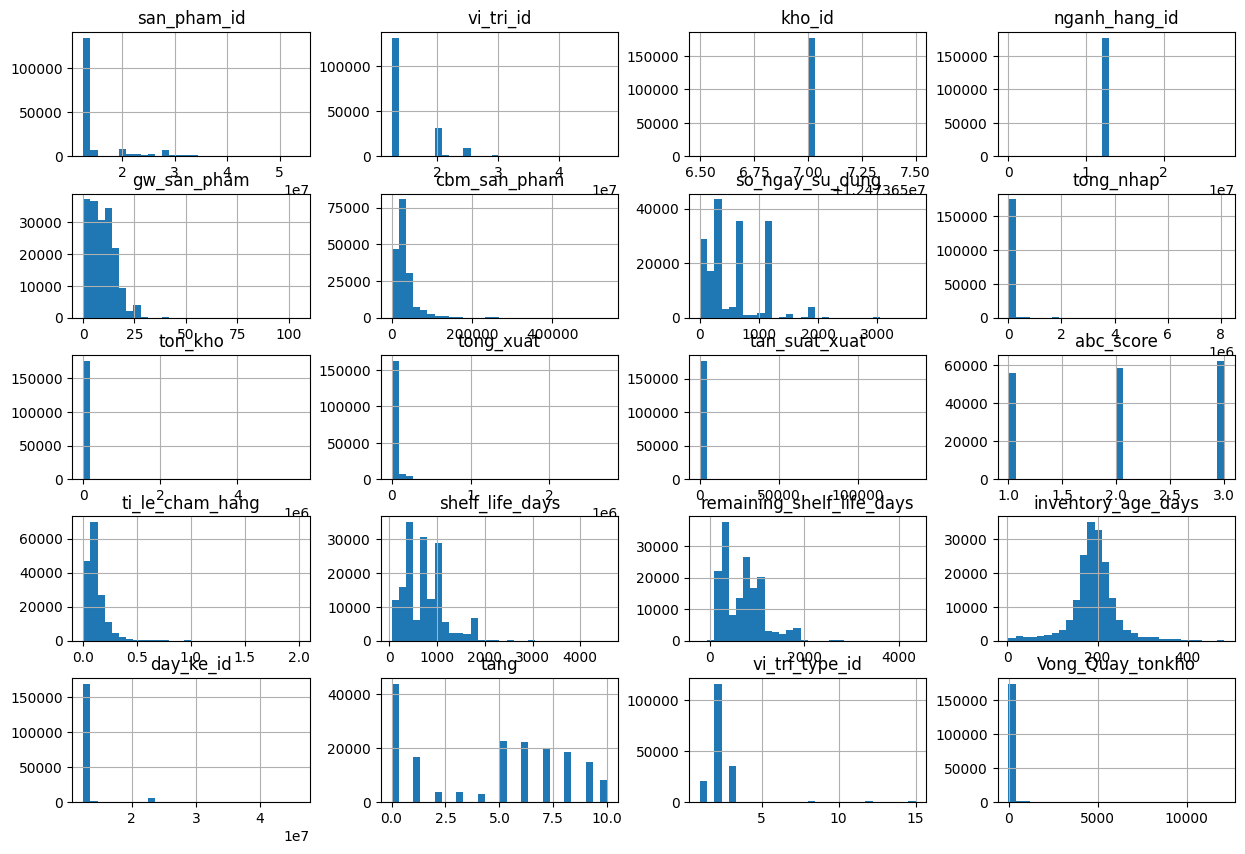

In [19]:
feature_kho_1.hist(
    figsize=(15,10),
    bins=30
)

In [20]:
feature_kho_1["vi_tri_id"].value_counts()

vi_tri_id
20036994    5767
20036974    4932
12473833    4292
20036980    4104
20036982    3117
            ... 
12496664       1
12474641       1
25074466       1
12474625       1
12475453       1
Name: count, Length: 14355, dtype: int64

## Vị trí

In [21]:
feature_kho_1["day_ke_id"].nunique()

feature_kho_1["day_ke_id"].value_counts().describe()

count       53.000000
mean      3337.113208
std       5558.907892
min          7.000000
25%        112.000000
50%       2832.000000
75%       5208.000000
max      38863.000000
Name: count, dtype: float64

In [22]:
feature_kho_1["tang"].nunique()

feature_kho_1["tang"].value_counts()

tang
0     43909
5     22608
6     22384
7     19843
8     18487
1     16699
9     14716
10     8168
2      3640
3      3573
4      2840
Name: count, dtype: int64

In [23]:
feature_kho_1["vi_tri_type_id"].value_counts()

vi_tri_type_id
2     116233
3      35693
1      21069
15      1475
8       1242
12       717
13       431
6          7
Name: count, dtype: int64